In [187]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

print("Environment ready")

Environment ready


In [188]:
from src.simulation import simulate_pump_data
from src.business_logic import *
from src.control_layer import simulate_actual_cash

In [189]:
fuel_df = simulate_pump_data()

daily_fuel = aggregate_daily_fuel(fuel_df)

white_bon_df = simulate_white_bon_usage(daily_fuel)
home_delivery_df = simulate_home_delivery(daily_fuel)
services_df = simulate_services()
debt_df = simulate_debt()

final_df = compute_expected_cash(
    daily_fuel,
    white_bon_df,
    home_delivery_df,
    services_df,
    debt_df
)

final_df = simulate_actual_cash(final_df)

final_df.head()

,date,diesel,gasoline,white_bon_gasoline,white_bon_diesel,diesel_home_delivery_liters,car_wash_revenue,oil_change_revenue,accessories_revenue,new_debt,old_debt_paid,net_gasoline_liters,net_diesel_liters,fuel_revenue,service_revenue,expected_cash,actual_cash,cash_gap
0,2023-01-01,6884.641159,2867.214671,107.388692,654.532684,172.581850,533.936859,352.398052,410.624169,1978.023027,824.317090,2759.825978,6230.108474,9162.516302,1296.959080,9305.769446,9703.140768,397.371322
1,2023-01-02,7244.192577,2944.344160,215.524209,433.679735,913.599809,344.200335,479.655419,363.233433,562.894604,115.934349,2728.819952,6810.512843,10452.932603,1187.089187,11193.061535,11082.450094,-110.611441
2,2023-01-03,7430.357243,2871.877508,44.806642,115.909501,200.086446,357.511820,504.536305,328.465843,888.938992,709.211955,2827.070865,7314.447742,10341.605054,1190.513969,11352.391985,11870.542815,518.150830
3,2023-01-04,7387.341666,2907.399322,16.887225,639.873913,360.884430,484.059197,780.263113,309.817388,97.044002,244.986672,2890.512097,6747.467753,9998.864280,1574.139698,11720.946648,12939.370533,1218.423885
4,2023-01-05,6905.201643,2990.582516,179.768404,488.938393,490.708584,371.060608,356.731851,226.264604,231.901423,941.087524,2810.814111,6416.263250,9717.785945,954.057063,11381.029110,11193.706410,-187.322700


In [190]:
median = final_df["cash_gap"].median()
mad = (final_df["cash_gap"] - median).abs().median()

final_df["robust_z"] = 0.6745 * (final_df["cash_gap"] - median) / mad
final_df["investigate_robust"] = final_df["robust_z"].abs() > 3

In [191]:
daily_volume = (
    final_df.groupby("date")[["gasoline","diesel"]]
    .sum()
    .reset_index()
)

daily_volume["gasoline_baseline"] = daily_volume["gasoline"].rolling(7).mean()
daily_volume["diesel_baseline"] = daily_volume["diesel"].rolling(7).mean()

daily_volume = daily_volume.dropna()

daily_volume["gasoline_dev"] = daily_volume["gasoline"] - daily_volume["gasoline_baseline"]
daily_volume["diesel_dev"] = daily_volume["diesel"] - daily_volume["diesel_baseline"]

In [192]:
def robust_z(series):
    median = series.median()
    mad = (series - median).abs().median()
    return 0.6745 * (series - median) / mad

daily_volume["gasoline_z"] = robust_z(daily_volume["gasoline_dev"])
daily_volume["diesel_z"] = robust_z(daily_volume["diesel_dev"])

In [193]:
final_df = final_df.merge(
    daily_volume[["date","gasoline_z","diesel_z"]],
    on="date",
    how="left"
)

In [194]:
final_df.loc[20,"actual_cash"] += 10000
final_df.loc[35,"gasoline"] += 5000
final_df.loc[40,"actual_cash"] += 15000

final_df["cash_gap"] = final_df["actual_cash"] - final_df["expected_cash"]

In [195]:
features = final_df[
    ["cash_gap","gasoline","diesel","service_revenue"]
]

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

iso = IsolationForest(
    contamination=0.06,
    random_state=42
)

preds = iso.fit_predict(scaled)

final_df["ml_anomaly_flag"] = preds == -1
final_df["ml_score"] = iso.decision_function(scaled)

In [196]:
final_df["cash_gap_ratio"] = final_df["cash_gap"] / final_df["expected_cash"]

final_df["gasoline_share"] = final_df["gasoline"] / (
    final_df["gasoline"] + final_df["diesel"]
)

final_df["service_to_fuel_ratio"] = final_df["service_revenue"] / final_df["fuel_revenue"]

In [197]:
final_df["risk_score"] = (
    final_df["investigate_robust"].astype(int) * 2
    + (final_df["gasoline_z"].abs() > 3).astype(int)
    + (final_df["diesel_z"].abs() > 3).astype(int)
)

def classify_risk(score):
    if score >= 3:
        return "HIGH"
    elif score == 2:
        return "MEDIUM"
    elif score == 1:
        return "LOW"
    else:
        return "NORMAL"

final_df["risk_level"] = final_df["risk_score"].apply(classify_risk)

In [198]:
def explain_row(row):

    reasons = []

    if abs(row["robust_z"]) > 3:
        reasons.append("Cash anomaly")

    if row["ml_anomaly_flag"]:
        reasons.append("ML anomaly")

    if abs(row["gasoline_z"]) > 3:
        reasons.append("Gasoline spike")

    if abs(row["diesel_z"]) > 3:
        reasons.append("Diesel spike")

    if len(reasons) == 0:
        return "Normal"

    return " | ".join(reasons)

final_df["anomaly_reason"] = final_df.apply(explain_row,axis=1)

In [199]:
assert (final_df["gasoline"] >= 0).all()
assert (final_df["diesel"] >= 0).all()
assert (final_df["actual_cash"] >= 0).all()

assert final_df["date"].is_monotonic_increasing
assert final_df["date"].nunique() == len(final_df)

assert (final_df["fuel_revenue"] >= 0).all()
assert (final_df["service_revenue"] >= 0).all()

assert (final_df["diesel"] < 20000).all()
assert (final_df["gasoline"] < 15000).all()

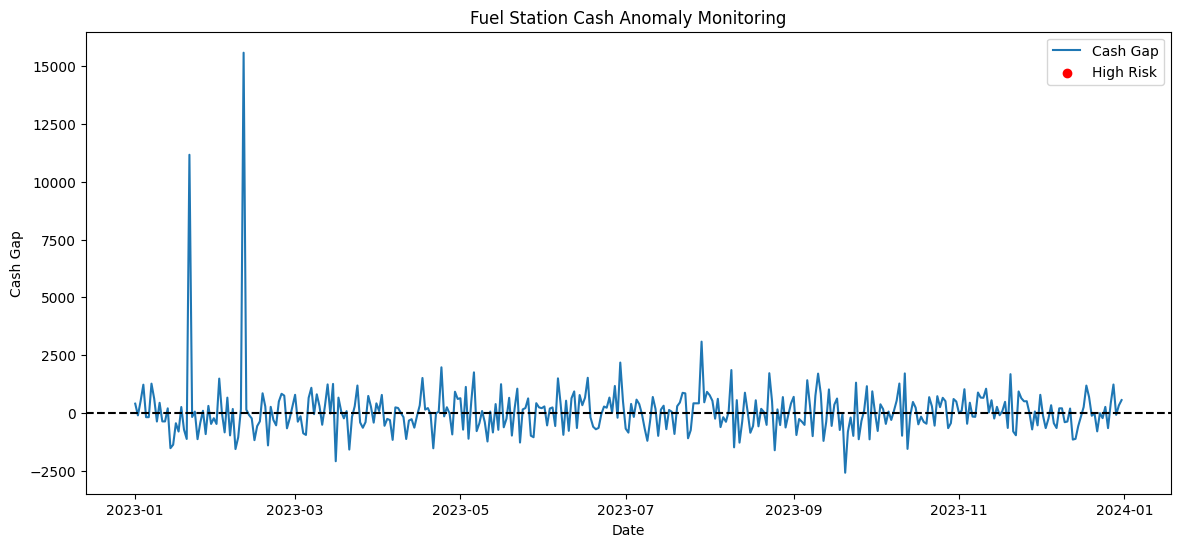

In [200]:
plt.figure(figsize=(14,6))

plt.plot(final_df["date"],final_df["cash_gap"],label="Cash Gap")

high_risk = final_df[final_df["risk_level"]=="HIGH"]

plt.scatter(
    high_risk["date"],
    high_risk["cash_gap"],
    color="red",
    label="High Risk"
)

plt.axhline(0,color="black",linestyle="--")

plt.title("Fuel Station Cash Anomaly Monitoring")
plt.xlabel("Date")
plt.ylabel("Cash Gap")
plt.legend()

plt.show()

In [201]:
monitoring_table = final_df[
    [
        "date",
        "cash_gap",
        "gasoline",
        "diesel",
        "risk_level",
        "anomaly_reason"
    ]
].copy()

In [202]:
alerts = monitoring_table[
    monitoring_table["risk_level"] != "Normal"
].sort_values("date")

In [203]:
alerts.head(10)

,date,cash_gap,gasoline,diesel,risk_level,anomaly_reason
0,2023-01-01,397.371322,2867.214671,6884.641159,NORMAL,Normal
1,2023-01-02,-110.611441,2944.344160,7244.192577,NORMAL,Normal
2,2023-01-03,518.150830,2871.877508,7430.357243,NORMAL,Normal
3,2023-01-04,1218.423885,2907.399322,7387.341666,NORMAL,Normal
4,2023-01-05,-187.322700,2990.582516,6905.201643,NORMAL,Normal
5,2023-01-06,-187.309566,2977.071740,6964.900583,NORMAL,ML anomaly
6,2023-01-07,1263.370252,2989.060285,8005.090667,NORMAL,Normal
7,2023-01-08,613.947783,2771.153208,7992.769999,NORMAL,Normal
8,2023-01-09,-375.579509,2842.242162,7067.814749,NORMAL,Normal
9,2023-01-10,434.048035,2879.882494,8745.103941,NORMAL,Normal


In [204]:
alerts["risk_level"].value_counts()

risk_level
NORMAL    363
MEDIUM      2
Name: count, dtype: int64

In [205]:
alerts.to_csv("fraud_alerts_report.csv", index=False)

In [206]:
# create ground truth
final_df["fraud_label"] = 0
final_df.loc[[20,35,40], "fraud_label"] = 1

pred = final_df["ml_anomaly_flag"].astype(int)
true = final_df["fraud_label"]

from sklearn.metrics import classification_report

print(classification_report(true, pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97       362
           1       0.14      1.00      0.24         3

    accuracy                           0.95       365
   macro avg       0.57      0.97      0.61       365
weighted avg       0.99      0.95      0.97       365



In [207]:
feature_corr = final_df[
    ["cash_gap","gasoline","diesel","service_revenue","ml_score"]
].corr()

feature_corr["ml_score"].sort_values()

cash_gap          -0.209809
gasoline          -0.088049
diesel             0.007009
service_revenue    0.047821
ml_score           1.000000
Name: ml_score, dtype: float64

In [208]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.06)
lof_pred = lof.fit_predict(scaled_features)

final_df["lof_flag"] = lof_pred == -1

In [209]:
final_df[["ml_anomaly_flag","lof_flag"]].value_counts()

ml_anomaly_flag  lof_flag
False            False       331
True             False        12
False            True         12
True             True         10
Name: count, dtype: int64

In [210]:
from sklearn.ensemble import RandomForestRegressor

features = final_df[[
    "diesel",
    "service_revenue",
    "gasoline_share"
]]

target = final_df["gasoline"]

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(features, target)

final_df["gasoline_pred"] = model.predict(features)

In [211]:
final_df["gasoline_prediction_error"] = (
    final_df["gasoline"] - final_df["gasoline_pred"]
)

In [212]:
features = final_df[
    [
        "cash_gap",
        "gasoline",
        "diesel",
        "service_revenue",
        "gasoline_share",
        "service_to_fuel_ratio"
    ]
].fillna(0)

In [213]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

In [214]:
import torch
import torch.nn as nn

class AutoEncoder(nn.Module):
    
    def __init__(self, input_dim):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 4)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

ModuleNotFoundError: No module named 'torch'

In [ ]:
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

model = AutoEncoder(input_dim=X_tensor.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

for epoch in range(200):
    
    optimizer.zero_grad()
    
    reconstructed = model(X_tensor)
    
    loss = criterion(reconstructed, X_tensor)
    
    loss.backward()
    optimizer.step()

In [ ]:
with torch.no_grad():
    
    reconstructed = model(X_tensor)
    
    errors = torch.mean((X_tensor - reconstructed) ** 2, dim=1)

final_df["ae_score"] = errors.numpy()

In [ ]:
threshold = final_df["ae_score"].quantile(0.95)

final_df["ae_anomaly"] = final_df["ae_score"] > threshold

In [ ]:
final_df["risk_score"] = (
    final_df["investigate_robust"].astype(int) * 2
    + (final_df["gasoline_z"].abs() > 3).astype(int)
    + (final_df["diesel_z"].abs() > 3).astype(int)
    + final_df["ml_anomaly_flag"].astype(int)
    + final_df["ae_anomaly"].astype(int)
)

In [ ]:
import shap

explainer = shap.Explainer(model, features)
shap_values = explainer(features)

In [215]:
shap.plots.bar(shap_values)

NameError: name 'shap' is not defined

In [ ]:
shap.plots.waterfall(shap_values[40])

In [ ]:
def explain_ml(i):
    
    vals = shap_values.values[i]
    feats = features.columns
    
    reasons = []
    
    for f,v in zip(feats, vals):
        if abs(v) > 0.2:
            reasons.append(f)
            
    return ", ".join(reasons)

final_df["ml_reason"] = [explain_ml(i) for i in range(len(final_df))]

In [ ]:
def recommend_action(row):

    if row["risk_level"] == "High Risk":
        return "Immediate audit of station cash records"

    if row["risk_level"] == "Medium Risk":
        return "Review fuel sales and pump activity"

    if row["risk_level"] == "Low Risk":
        return "Monitor for repeated anomalies"

    return "No action"

In [ ]:
final_df["recommended_action"] = final_df.apply(recommend_action, axis=1)

In [ ]:
alerts.to_csv("fuel_station_alerts.csv", index=False)

In [ ]:
def load_operational_data():

    fuel = pd.read_csv("data/pump_sales.csv")
    services = pd.read_csv("data/services.csv")
    debts = pd.read_csv("data/debts.csv")

    return fuel, services, debts

In [ ]:
def train_models(df):

    features = df[
        ["cash_gap","gasoline","diesel","service_revenue"]
    ]

    scaler = StandardScaler()
    X = scaler.fit_transform(features)

    model = IsolationForest(
        contamination=0.05,
        random_state=42
    )

    model.fit(X)

    return model, scaler

In [ ]:
import joblib
joblib.dump(model, "models/anomaly_model.pkl")

In [ ]:
def generate_alerts(df):

    alerts = df[df["risk_level"] == "High Risk"]

    for _, row in alerts.iterrows():

        print(
            f"""
            ALERT 🚨
            Date: {row['date']}
            Reason: {row['anomaly_reason']}
            Cash Gap: {row['cash_gap']}
            """
        )

In [ ]:
features_df = create_features(final_df)

features_df.to_parquet("feature_store/fuel_features.parquet")

In [ ]:
features = features_df[
    [
        "cash_gap",
        "gasoline",
        "diesel",
        "service_revenue",
        "cash_gap_ratio",
        "gasoline_share",
        "service_to_fuel_ratio"
    ]
]

In [ ]:
features_df.describe()